---
#  Clase 05: Imágenes Sentinel-2: Lectura, recortes y combinación de resoluciones
---

En esta clase utilizaremos una escena satelital Sentinel-2 correspondiente a la zona del dique Roggero, Buenos Aires, sobre la cual trabajaremos en las siguientes Notebooks. Nos basaremos en las funciones de lectura para este tipo de imágenes vistas en el [video complementario](https://drive.google.com/file/d/1vuPc91UNRxvekQfort2SHp11kS2Dc_s4/view?usp=sharing), las cuales deben estar ya incorporadas a tu archivo `funciones.py`. 

### Objetivos de la notebook:

- [x] Aplicar las funciones de la Notebook complementaria para leer la escena Sentinel-2 del Dique Roggero, extraer un recorte y combinar distintas resoluciones. 

### Datos con los que trabajaremos en esta Notebook:

- Escena Sentinel-2 del dique Roggero que debe estar descargada en **data/S2A_MSIL2A_20181006T135111_N0500_R024_T21HUB_20230728T190033.SAFE.zip*** * (enlace de descarga [aquí](https://drive.google.com/file/d/1j22BMxzsZTaLLHUHX7wMD-6d4QO3_xgY/view?usp=sharing))
- El archivo vectorial encuadrando la zona del Dique Roggero: **data/zona_dique.geojson** (enlace de descarga [aquí](https://drive.google.com/file/d/1YJcfHGbILIAcmap3y6aaMuSYoWnP2eOH/view?usp=sharing))

### Tile T21HUB y Zona del Dique Roggero: 
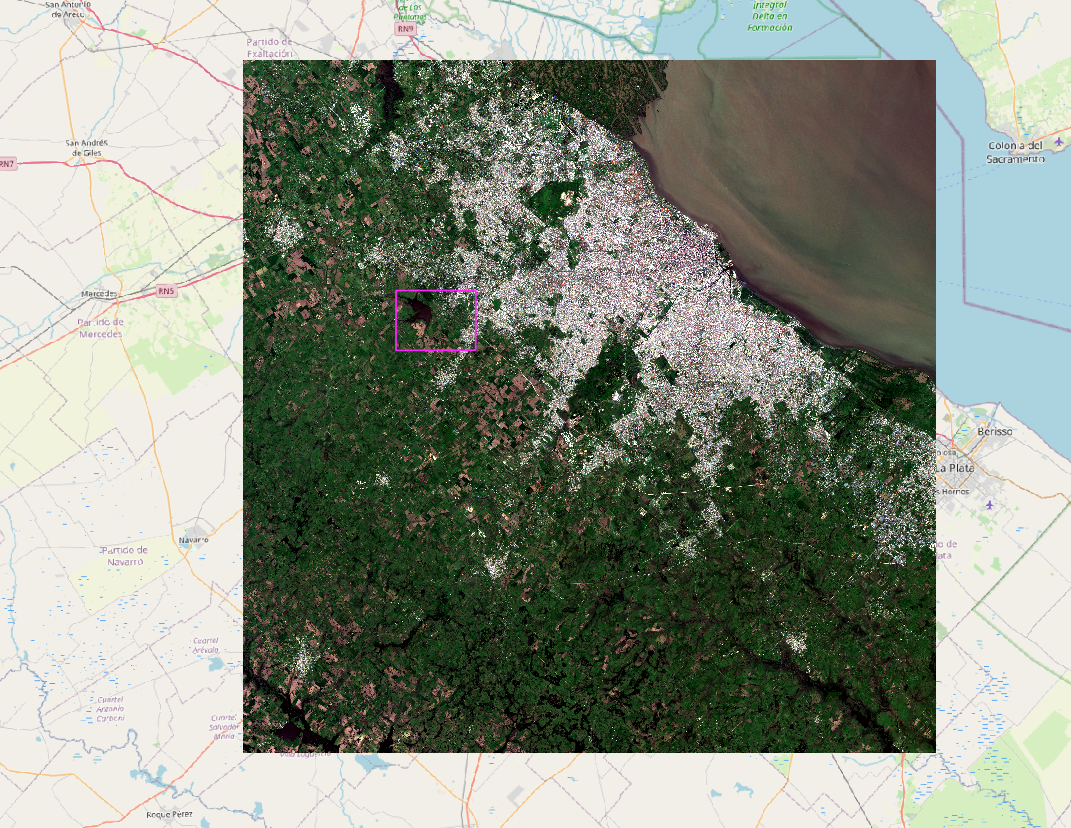

## 1. Lectura y escritura de recortes de la escena Sentinel-2.

Vamos a aplicar las funciones `leer_bandas_l2a`y `resample_bands` de `funciones.py`para extraer las bandas de interés, y vamos a guardar el recorte generado. Además, incorporaremos una nueva función para alinear nuestro polígono a la grilla de Sentinel, evitando problemas de bordes sin datos.

Las librerías que vamos a utilizar son:

```python
import os
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd

import rasterio
from rasterio.mask import mask
from shapely.geometry import shape

import funciones as fn
```

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd

import rasterio
from rasterio.mask import mask
from shapely.geometry import shape

import funciones as fn

### 1.1. Ajuste del polígono a la grilla de Sentinel:

Comencemos por leer el vector con nuestra zona de inteŕes, `zona_dique.geojson`:


```python

zona_dique = gpd.read_file('data/zona_dique.geojson')

print(zona_dique.total_bounds)
```

In [2]:
zona_dique = gpd.read_file('data/zona_dique.geojson')

print(zona_dique.total_bounds)

[ 324185.46643365 6153997.92597043  336865.80070831 6163499.81233983]


En el caso de Sentinel-2, si abrimos nuestras imágenes veremos que las esquinas de los pixeles coinciden con un valor de coordenadas que corresponde a un múltiplo de la resolución de la banda (10, 20 o 60 según sea el caso). Cuando aplicamos recortes con vectores que no se ajustan exactamente a esa grilla, `mask` toma decisiones sobre qué hacer con los píxeles que quedan en el borde, pudiendo dar lugar a situaciones como esta:

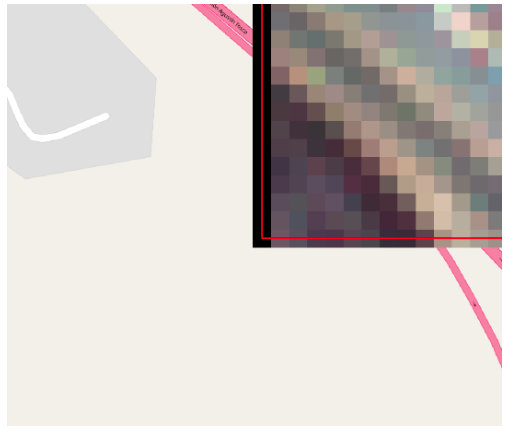

Para evitar este problema, podemos construir una función que lea nuestro polígono, extraiga su extensión con `total_bounds`, y luego la ajuste a una grilla de resolución específica. Vamos a llamarle a esa función `ajustar_poligono`:

```python
def ajustar_poligono(poligono, snap_to_grid = True, grid_step = 10):
    """dado un vector de polígonos, calcula el mínimo rectángulo que lo contiene, usando vértices
    en una grilla de paso dado."""

    x_min, y_min, x_max, y_max = poligono.total_bounds
    if snap_to_grid:
        x_min = grid_step*np.floor(x_min/grid_step)
        x_max = grid_step*np.ceil(x_max/grid_step)
        y_min = grid_step*np.floor(y_min/grid_step)
        y_max = grid_step*np.ceil(y_max/grid_step)

    min_r = shape({'type': 'Polygon',
          'coordinates': [((x_min, y_max),
                           (x_max, y_max),
                           (x_max, y_min),
                           (x_min, y_min),
                           (x_min, y_max))]})
    return gpd.GeoDataFrame(geometry=[min_r], crs=poligono.crs)
```

Esta función va a devolver un nuevo `Geodataframe` rectangular que, si `snap_to_grid = True`, estará ajustado a la grilla de la resolución especificada en `grid_step`. Veamos cómo aplicarla sobre `zona_dique`:

```python
zona_dique_ajustado = ajustar_poligono(zona_dique)

print('Extensión del polígono ajustado:' \n)
print(zona_dique_ajustado.total_bounds)
```

In [3]:
def ajustar_poligono(poligono, snap_to_grid = True, grid_step = 10):
    """dado un vector de polígonos, calcula el mínimo rectángulo que lo contiene, usando vértices
    en una grilla de paso dado."""

    x_min, y_min, x_max, y_max = poligono.total_bounds
    if snap_to_grid:
        x_min = grid_step*np.floor(x_min/grid_step)
        x_max = grid_step*np.ceil(x_max/grid_step)
        y_min = grid_step*np.floor(y_min/grid_step)
        y_max = grid_step*np.ceil(y_max/grid_step)

    min_r = shape({'type': 'Polygon',
          'coordinates': [((x_min, y_max),
                           (x_max, y_max),
                           (x_max, y_min),
                           (x_min, y_min),
                           (x_min, y_max))]})
    return gpd.GeoDataFrame(geometry=[min_r], crs=poligono.crs)

zona_dique_ajustado = ajustar_poligono(zona_dique)

print('Extensión del polígono ajustado:\n')
print(zona_dique_ajustado.total_bounds)

Extensión del polígono ajustado:

[ 324180. 6153990.  336870. 6163500.]


### 1.2. Lectura y remuestreo de las bandas de interés

Ahora sí, vamos a leer la Sentinel-2 con `leer_bandas_l2a` y extraer las bandas 02,03,04,08 por un lado, y 11,12 por el otro:

```python
zipfilename = 'data/S2A_MSIL2A_20181006T135111_N0500_R024_T21HUB_20230728T190033.SAFE.zip'

stack_10m, metadatos_10m = fn.leer_bandas_l2a(zipfilename, bands_to_extract = ['B02','B03','B04','B08'], res = 10, poligono=zona_dique_ajustado)
stack_20m, metadatos_20m = fn.leer_bandas_l2a(zipfilename, bands_to_extract = ['B11','B12'], res = 20, poligono=zona_dique_ajustado)

print("Dimensiones del stack a 10 metros: ", stack_10m.shape)
print("Dimensiones del stack a 20 metros: ", stack_20m.shape)
```

In [4]:
zipfilename = 'data/S2A_MSIL2A_20181006T135111_N0500_R024_T21HUB_20230728T190033.SAFE.zip'

stack_10m, metadatos_10m = fn.leer_bandas_l2a(zipfilename, bands_to_extract = ['B02','B03','B04','B08'], res = 10, poligono=zona_dique_ajustado)
stack_20m, metadatos_20m = fn.leer_bandas_l2a(zipfilename, bands_to_extract = ['B11','B12'], res = 20, poligono=zona_dique_ajustado)

print("Dimensiones del stack a 10 metros: ", stack_10m.shape)
print("Dimensiones del stack a 20 metros: ", stack_20m.shape)

Dimensiones del stack a 10 metros:  (4, 951, 1269)
Dimensiones del stack a 20 metros:  (2, 476, 635)


A continuación, llamamos a `resample_bands` para remuestrear `stack_20m` de 20 a 10 metros de resolución:

```python
# Remuestrar las bandas de 20 a la resolución de stack_10m
stack_b11_b12_10m = fn.resample_bands(stack_20m, stack_10m)
print(f'Dimensiones del stack remuestreado: {stack_b11_b12_10m.shape}')
```

In [5]:
# Remuestrar las bandas de 20 a la resolución de stack_10m
stack_b11_b12_10m = fn.resample_bands(stack_20m, stack_10m)
print(f'Dimensiones del stack remuestreado: {stack_b11_b12_10m.shape}')

Dimensiones del stack remuestreado: (2, 951, 1269)


Finalmente, juntamos todo en un único `stack`:

```python
stack_final = np.concatenate((stack_10m, stack_b11_b12_10m), axis = 0)
print(f'Dimensiones del stack final: {stack_final.shape}')
```

In [6]:
stack_final = np.concatenate((stack_10m, stack_b11_b12_10m), axis = 0)
print(f'Dimensiones del stack final: {stack_final.shape}')

Dimensiones del stack final: (6, 951, 1269)


### 1.3. Visualización del stack final y guardado

Para asegurarnos de la correcta extracción, visualicemos `stack_final`, y luego lo guardaremos para volver a utilizar en las siguientes clases

```python
imagen_escalada = fn.scale_multiband(stack_final, p=2)

fig, ax = plt.subplots(figsize = (12,8))
ax.imshow(imagen_escalada[[2,1,0]].transpose(1,2,0))
ax.set_title("Recorte extraído sobre el dique Roggero")
plt.show()
```

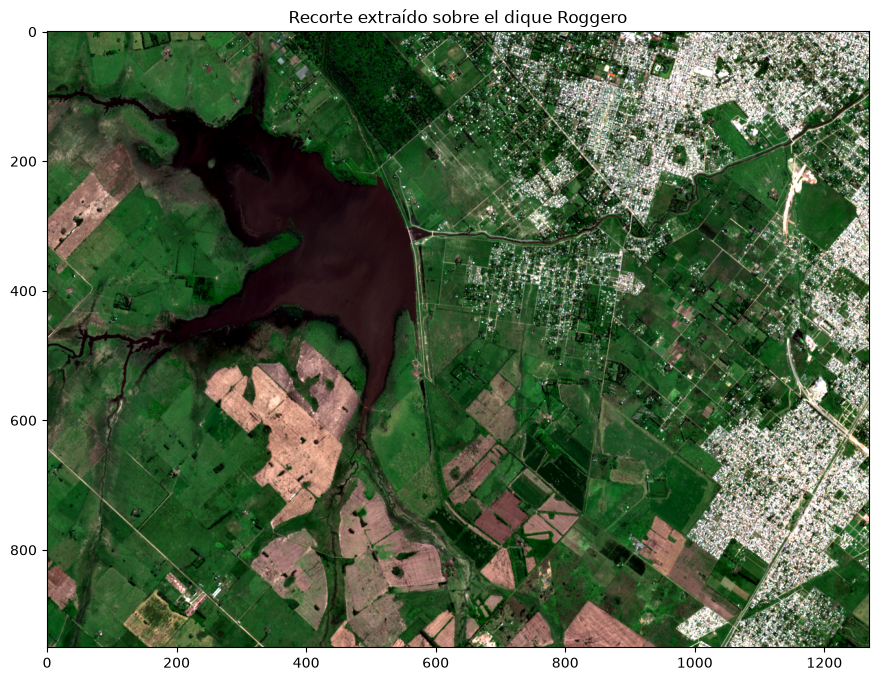

In [7]:
imagen_escalada = fn.scale_multiband(stack_final, p=2)

fig, ax = plt.subplots(figsize = (12,8))
ax.imshow(imagen_escalada[[2,1,0]].transpose(1,2,0))
ax.set_title("Recorte extraído sobre el dique Roggero")
plt.show()

Vamos a guardar la imagen agregando descripciones a las bandas. Tenemos que actualizar los metadatos, para lo cual podemos tomar como base `metadatos_10m` y modificar las dimensione de la matriz de salida:

```python
metadatos_final = metadatos_10m.copy()

# Definir un nombre y ruta de salida
raster_fn = 'output/S2_20181006.tif'

#Actualizar las dimensiones de salida (número de bandas solamente)
metadatos_final['count'] = stack_final.shape[0]

# Lista de bandas para set_band_description:
band_list = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

# Abrir el archivo en modo escritura
with rasterio.open(raster_fn, 'w+', **metadatos_final) as dst:
  for i,b in enumerate(band_list):
    dst.set_band_description(i+1, b) #Agregar una descripción del nombre de la banda desde band_list
  dst.write(stack_final) #Escribir el array
```

In [8]:
metadatos_final = metadatos_10m.copy()

# Definir un nombre y ruta de salida
raster_fn = 'output/S2_20181006.tif'

#Actualizar las dimensiones de salida (número de bandas solamente)
metadatos_final['count'] = stack_final.shape[0]

# Lista de bandas para set_band_description:
band_list = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

# Abrir el archivo en modo escritura
with rasterio.open(raster_fn, 'w+', **metadatos_final) as dst:
  for i,b in enumerate(band_list):
    dst.set_band_description(i+1, b) #Agregar una descripción del nombre de la banda desde band_list
  dst.write(stack_final) #Escribir el array